<figure style="text-align: left; margin: 1em 0; float: right">
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/55/ImmoScout24_Logo_2020.svg/960px-ImmoScout24_Logo_2020.svg.png" alt="ImmoScout24 Logo" width="500">
    <figcaption style="font-size: 0.85em; color: #555555; margin-top: 0.6em; font-family: sans-serif; line-height: 1.4;">
        <p>Abbildung 1: Immobilien Scout GmbH (2020). </p>
        <p><i>Unternehmenslogo ImmoScout24</i> [Grafik]. Verfügbar unter: </p>
        <a href="https://www.immobilienscout24.de/redesign/images/footer/Scout24_IMMO_Logo_Stacked_Solid_w3000px_RGB.svg" style="color: #1fc0cf; text-decoration: none;">https://www.immobilienscout24.de/redesign/images/footer/Scout24_IMMO_Logo_Stacked_Solid_w3000px_RGB.svg</a> 
        <p>[Abgerufen am 18 Mai 2026].</p>
    </figcaption>
</figure>

# Vorhersage von Mieten einer Wohnung

## Inhaltsverzeichnis

### [1. Einführung & Setup](#setup)
#### [1.1. Bibliotheken & Datenimport](#libraries)

### [2. Explorative Datenanalyse & Data Cleaning](#eda)
#### [2.1. Datenbereinigung & Imputation](#miete)
#### [2.2. Feature Encoding](#flaeche)

### [3. Multikollinearitätsanalyse (VIF)](#vif)

### [4. Outlier-Strategien & Vergleich](#outlier)

### [5. Lineares Regressionsmodell](#regression)
#### [5.1. Modelltraining & Baseline](#baseline)
#### [5.2. Ergebnis Interpretation](#heizkosten)

In [1]:
import os
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import make_scorer, mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

<hr style="height:10px; border:none; border-radius: 25px; background-image: linear-gradient(to right, #3df5dc, #1fc0cf, #478aa7, #4c5a6d, #333333);">

# Mietpreisvorhersage – Modellierung
<h2 id="1-einfuehrung">1. Einführung & Setup</h2>
Wir laden den Datensatz.

In [2]:
df_outlier = pd.read_csv('/kaggle/input/datasets/yorkbusche/df-clean-outlier-imputed/df_clean_outlier_imputed.csv')
df_isolation = pd.read_csv('/kaggle/input/datasets/yorkbusche/df-clean-isolation-imputed/df_clean_isolation_imputed.csv')
df_hardlimits = pd.read_csv('/kaggle/input/datasets/yorkbusche/df-clean-hardlimits-imputed/df_clean_hardlimits_imputed.csv')

<hr style="height:10px; border:none; border-radius: 25px; background-image: linear-gradient(to right, #3df5dc, #1fc0cf, #478aa7, #4c5a6d, #333333);">

<h2 id="2-eda--cleaning">2. Explorative Datenanalyse & Data Cleaning</h2>

### 2.1 Train/Test Split
Der Datensatz wird im Verhältnis 80/20 in Trainings- und Testdaten aufgeteilt.

In [3]:
def encode_firing_types(df):
    firing_dummies = df['firingTypes'].str.get_dummies(sep=':')
    firing_dummies = firing_dummies.add_prefix('firing_')
    df = df.drop(columns=['firingTypes'])
    df = pd.concat([df, firing_dummies], axis=1)
    return df

df_outlier = encode_firing_types(df_outlier)
df_isolation = encode_firing_types(df_isolation)
df_hardlimits = encode_firing_types(df_hardlimits)

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df_outlier.describe()
df_isolation.describe()
df_hardlimits.describe()

,pricetrend,telekomUploadSpeed,yearConstructed,baseRent,livingSpace,noRooms,thermalChar,heatingCosts,lastRefurbish,electricityKwhPrice,noParkSpaces_missing,telekomUploadSpeed_missing,heatingCosts_missing,thermalChar_missing,lastRefurbish_missing,numberOfFloors_missing,interiorQual_missing,typeOfFlat_missing,condition_missing,telekomTvOffer_missing,firing_bio_energy,firing_coal,firing_coal_coke,firing_combined_heat_and_power_bio_energy,firing_combined_heat_and_power_fossil_fuels,firing_combined_heat_and_power_regenerative_energy,firing_combined_heat_and_power_renewable_energy,firing_district_heating,firing_electricity,firing_environmental_thermal_energy,firing_gas,firing_geothermal,firing_heat_supply,firing_hydro_energy,firing_liquid_gas,firing_local_heating,firing_natural_gas_heavy,firing_natural_gas_light,firing_oil,firing_pellet_heating,firing_solar_heating,firing_steam_district_heating,firing_wind_energy,firing_wood,firing_wood_chips
count,250964.000000,250964.000000,250964.000000,2.509640e+05,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000,250964.000000
mean,3.381958,30.226640,1967.736428,6.946697e+02,74.241034,2.635283,109.919494,79.030112,2015.197821,0.199775,0.654265,0.123747,0.674531,0.371248,0.743382,0.370993,0.434604,0.138550,0.265389,0.121085,0.000622,0.000235,0.000036,0.000048,0.003566,0.000394,0.000725,0.193382,0.026386,0.003534,0.625205,0.009770,0.001526,0.000199,0.001674,0.004339,0.018046,0.038177,0.067755,0.009754,0.003750,0.003024,0.000068,0.000797,0.000717
std,1.962321,15.722662,43.545041,2.021976e+04,263.491921,2.395056,50.047518,87.092633,4.464012,0.004724,0.475608,0.329293,0.468551,0.483140,0.436768,0.483072,0.495706,0.345477,0.441541,0.326227,0.024924,0.015331,0.005988,0.006915,0.059612,0.019858,0.026920,0.394951,0.160281,0.059346,0.484071,0.098361,0.039036,0.014114,0.040875,0.065730,0.133120,0.191623,0.251325,0.098282,0.061119,0.054911,0.008230,0.028219,0.026772
min,-12.330000,1.000000,1000.000000,1.000000e+00,1.000000,1.000000,0.100000,0.000000,1898.000000,0.170500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.980000,10.000000,1956.000000,3.350000e+02,54.000000,2.000000,83.400000,66.070000,2015.000000,0.198500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.380000,40.000000,1971.000000,4.850950e+02,67.000000,3.000000,107.000000,76.000000,2017.000000,0.198500,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.570000,40.000000,1995.000000,7.950000e+02,86.010000,3.000000,119.000000,85.000000,2018.000000,0.198500,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.00

In [6]:
X_outlier = df_outlier.drop(columns=['baseRent'])
y_outlier = df_outlier['baseRent']

X_train_outlier, X_test_outlier, y_train_outlier, y_test_outlier = train_test_split(
    X_outlier, y_outlier, test_size=0.2, random_state=42
)


X_isolation = df_isolation.drop(columns=['baseRent'])
y_isolation = df_isolation['baseRent']


X_train_isolation, X_test_isolation, y_train_isolation, y_test_isolation = train_test_split(
    X_isolation, y_isolation,
    test_size=0.2,
    random_state=42
)


X_hardlimits = df_hardlimits.drop(columns=['baseRent'])
y_hardlimits = df_hardlimits['baseRent']

X_train_hardlimits, X_test_hardlimits, y_train_hardlimits, y_test_hardlimits = train_test_split(
    X_hardlimits, y_hardlimits,
    test_size=0.2,
    random_state=42
)

### 2.3 One-Hot Encoding
Kategoriale Features werden mittels get_dummies in numerische Werte umgewandelt. 
Die Spalten von Test- und Trainingsdaten werden anschließend mit align() angeglichen, 
um mögliche Spaltenunterschiede zu vermeiden.

In [7]:
X_train_encoded_outlier = pd.get_dummies(X_train_outlier, drop_first=True)
X_test_encoded_outlier = pd.get_dummies(X_test_outlier, drop_first=True)

X_final_train_outlier, X_final_test_outlier = X_train_encoded_outlier.align(
    X_test_encoded_outlier, join='left', axis=1, fill_value=0)

X_train_encoded_isolation = pd.get_dummies(X_train_isolation, drop_first=True)
X_test_encoded_isolation = pd.get_dummies(X_test_isolation, drop_first=True)

X_final_train_isolation, X_final_test_isolation = X_train_encoded_isolation.align(X_test_encoded_isolation, join='left', axis=1, fill_value=0)

X_train_encoded_hardlimits = pd.get_dummies(X_train_hardlimits, drop_first=True)
X_test_encoded_hardlimits = pd.get_dummies(X_test_hardlimits, drop_first=True)

X_final_train_hardlimits, X_final_test_hardlimits = X_train_encoded_hardlimits.align(X_test_encoded_hardlimits, join='left', axis=1, fill_value=0)

In [8]:
print(
    f"Outlier (nach OHE):          {len([c for c in X_train_encoded_outlier.columns if 'geo_krs' in c])}"
)
print(
    f"Isolation Forest (nach OHE): {len([c for c in X_train_encoded_isolation.columns if 'geo_krs' in c])}"
)
print(
    f"Hard Limits (nach OHE):      {len([c for c in X_train_encoded_hardlimits.columns if 'geo_krs' in c])}"
)

Outlier (nach OHE):          418
Isolation Forest (nach OHE): 418
Hard Limits (nach OHE):      418


In [9]:
# Seltene Spalten (< 100 Vorkommen im Training) systematisch entfernen
min_count = 100

for name, X_train, X_test in [
    ('outlier', X_final_train_outlier, X_final_test_outlier),
    ('isolation', X_final_train_isolation, X_final_test_isolation),
    ('hardlimits', X_final_train_hardlimits, X_final_test_hardlimits)
]:
    rare_cols = [col for col in X_train.columns 
                 if X_train[col].nunique() == 2 and X_train[col].sum() < min_count]
    
    print(f"{name}: entferne {len(rare_cols)} seltene Spalten")
    
    X_train.drop(columns=rare_cols, inplace=True, errors='ignore')
    X_test.drop(columns=rare_cols, inplace=True, errors='ignore')

outlier: entferne 110 seltene Spalten
isolation: entferne 109 seltene Spalten
hardlimits: entferne 104 seltene Spalten


In [10]:
print(
    f"Outlier-Bereinigung: {len([c for c in X_final_train_outlier.columns if 'geo_krs' in c])}"
)
print(
    f"Isolation Forest:   {len([c for c in X_final_train_isolation.columns if 'geo_krs' in c])}"
)
print(
    f"Hard Limits:        {len([c for c in X_final_train_hardlimits.columns if 'geo_krs' in c])}"
)

Outlier-Bereinigung: 315
Isolation Forest:   316
Hard Limits:        321


<h2 id="3-vif-analyse">3. Multikollinearitätsanalyse (VIF)</h2>

In [11]:
warnings.filterwarnings('ignore')

for name, X in [('outlier', X_final_train_outlier), 
                ('isolation', X_final_train_isolation), 
                ('hardlimits', X_final_train_hardlimits)]:
    
    vif_cols = [col for col in X.columns 
                if not col.startswith('geo_krs')
                and not col.startswith('geo_bln')]
    
    # Nur 10% der Daten
    X_sample = X[vif_cols].sample(frac=0.1, random_state=42)
    
    vif_data = pd.DataFrame()
    vif_data['Feature'] = vif_cols
    vif_data['VIF'] = [variance_inflation_factor(
                        X_sample.values.astype(float), i) 
                       for i in range(len(vif_cols))]
    
    print(f"=== {name.upper()} ===")
    print(vif_data.sort_values('VIF', ascending=False).head(20))
    print()

=== OUTLIER ===
                                 Feature          VIF
11                         lastRefurbish  7535.451533
4                        yearConstructed  5320.033834
12                   electricityKwhPrice  1822.468076
29                            firing_gas    51.908064
14            telekomUploadSpeed_missing    38.374492
22                telekomTvOffer_missing    38.248635
62                   interiorQual_normal    37.395447
6                            livingSpace    31.758985
8                                noRooms    26.502149
78               energyEfficiencyClass_C    24.588397
64            interiorQual_sophisticated    17.870706
26               firing_district_heating    16.720881
79               energyEfficiencyClass_D    16.272621
77               energyEfficiencyClass_B    11.740857
61                   condition_well_kept    11.423119
84  energyEfficiencyClass_NO_INFORMATION    10.545536
9                            thermalChar     8.803382
36          

In [12]:
#Die Features mit den höchsten VIF
print("=== yearConstructed vs. lastRefurbish vs. electricityKwhPrice ===")
print(X_final_train_outlier[['yearConstructed', 'lastRefurbish', 'electricityKwhPrice']].corr())
print()

print("=== telekomUploadSpeed_missing vs. telekomTvOffer_missing ===")
print(X_final_train_outlier[['telekomUploadSpeed_missing', 'telekomTvOffer_missing']].corr())
print()
print(pd.crosstab(X_final_train_outlier['telekomUploadSpeed_missing'], 
                   X_final_train_outlier['telekomTvOffer_missing']))

=== yearConstructed vs. lastRefurbish vs. electricityKwhPrice ===
                     yearConstructed  lastRefurbish  electricityKwhPrice
yearConstructed             1.000000       0.247027            -0.106625
lastRefurbish               0.247027       1.000000            -0.245088
electricityKwhPrice        -0.106625      -0.245088             1.000000

=== telekomUploadSpeed_missing vs. telekomTvOffer_missing ===
                            telekomUploadSpeed_missing  telekomTvOffer_missing
telekomUploadSpeed_missing                    1.000000                0.987603
telekomTvOffer_missing                        0.987603                1.000000

telekomTvOffer_missing           0      1
telekomUploadSpeed_missing               
0                           166851      0
1                              501  22575


In [13]:
# Welche Features erklären lastRefurbish am besten?
other_cols = [c for c in X_final_train_outlier.columns if c != 'lastRefurbish']
temp_model = LinearRegression().fit(X_final_train_outlier[other_cols], X_final_train_outlier['lastRefurbish'])
r2_lastRefurbish = temp_model.score(X_final_train_outlier[other_cols], X_final_train_outlier['lastRefurbish'])
print(f"R² von lastRefurbish erklärt durch alle anderen Features: {r2_lastRefurbish:.4f}")

# Größte Koeffizienten anzeigen, um zu sehen, welche Features am meisten beitragen
coef_df = pd.DataFrame({'Feature': other_cols, 'Coef': temp_model.coef_})
print(coef_df.sort_values('Coef', key=abs, ascending=False).head(10))

R² von lastRefurbish erklärt durch alle anderen Features: 0.3417
                                          Feature       Coef
11                            electricityKwhPrice -79.508309
303                  geo_krs_Saale_Holzland_Kreis  -7.325383
282                        geo_krs_Prignitz_Kreis  -5.208199
358                                geo_krs_Wismar  -3.744715
16                          lastRefurbish_missing   3.258022
368  condition_first_time_use_after_refurbishment   3.078931
348                         geo_krs_Wartburgkreis  -3.006183
140                                  geo_krs_Gera  -2.977394
73                          geo_krs_Bautzen_Kreis  -2.506418
56                 geo_krs_Altenburger_Land_Kreis  -2.500666


In [14]:
# 30% statt 10%, um zu sehen ob die Werte sich stabilisieren
X_sample = X_final_train_outlier[vif_cols].sample(frac=0.3, random_state=42)

vif_data = pd.DataFrame()
vif_data['Feature'] = vif_cols
vif_data['VIF'] = [variance_inflation_factor(X_sample.values.astype(float), i) 
                   for i in range(len(vif_cols))]
print(vif_data.sort_values('VIF', ascending=False).head(20))

                                 Feature          VIF
11                         lastRefurbish  7625.822455
4                        yearConstructed  5290.570535
12                   electricityKwhPrice  1938.496735
29                            firing_gas    58.408184
14            telekomUploadSpeed_missing    43.108996
22                telekomTvOffer_missing    43.022634
62                   interiorQual_normal    38.368509
6                            livingSpace    31.539017
8                                noRooms    26.197423
78               energyEfficiencyClass_C    24.274180
26               firing_district_heating    18.754729
64            interiorQual_sophisticated    18.696649
79               energyEfficiencyClass_D    16.013599
77               energyEfficiencyClass_B    11.625412
61                   condition_well_kept    11.240657
84  energyEfficiencyClass_NO_INFORMATION    10.595238
9                            thermalChar     8.590919
36                          

In [15]:
for X_train, X_test in [(X_final_train_outlier, X_final_test_outlier),
                         (X_final_train_isolation, X_final_test_isolation),
                         (X_final_train_hardlimits, X_final_test_hardlimits)]:
    
    for df in [X_train, X_test]:
        df['telekom_info_missing'] = (
            (df['telekomUploadSpeed_missing'] == 1) | 
            (df['telekomTvOffer_missing'] == 1)
        ).astype(int)
        df.drop(columns=['telekomUploadSpeed_missing', 'telekomTvOffer_missing'], 
                inplace=True, errors='ignore')

In [16]:
for name, X in [('outlier', X_final_train_outlier), 
                ('isolation', X_final_train_isolation), 
                ('hardlimits', X_final_train_hardlimits)]:
    
    vif_cols = [col for col in X.columns 
                if not col.startswith('geo_krs')
                and not col.startswith('geo_bln')]
    
    X_sample = X[vif_cols].sample(frac=0.1, random_state=42)
    X_sample_const = sm.add_constant(X_sample.astype(float))  # Konstante
    
    vif_data = pd.DataFrame()
    vif_data['Feature'] = vif_cols
    vif_data['VIF'] = [variance_inflation_factor(X_sample_const.values, i+1) 
                       for i in range(len(vif_cols))]
    
    print(f"=== {name.upper()} ===")
    print(vif_data.sort_values('VIF', ascending=False).head(20))
    print()

=== OUTLIER ===
                                 Feature        VIF
27                            firing_gas  19.247066
76               energyEfficiencyClass_C  16.203689
60                   interiorQual_normal  14.034718
24               firing_district_heating  13.532212
77               energyEfficiencyClass_D  12.559597
62            interiorQual_sophisticated  11.703277
75               energyEfficiencyClass_B   9.616156
82  energyEfficiencyClass_NO_INFORMATION   8.961213
34                            firing_oil   6.371357
59                   condition_well_kept   5.836925
33              firing_natural_gas_light   3.968482
6                            livingSpace   3.579486
78               energyEfficiencyClass_E   3.028785
58                 condition_refurbished   3.019522
53             condition_fully_renovated   2.835617
8                                noRooms   2.750678
32              firing_natural_gas_heavy   2.354838
79               energyEfficiencyClass_F   2.316

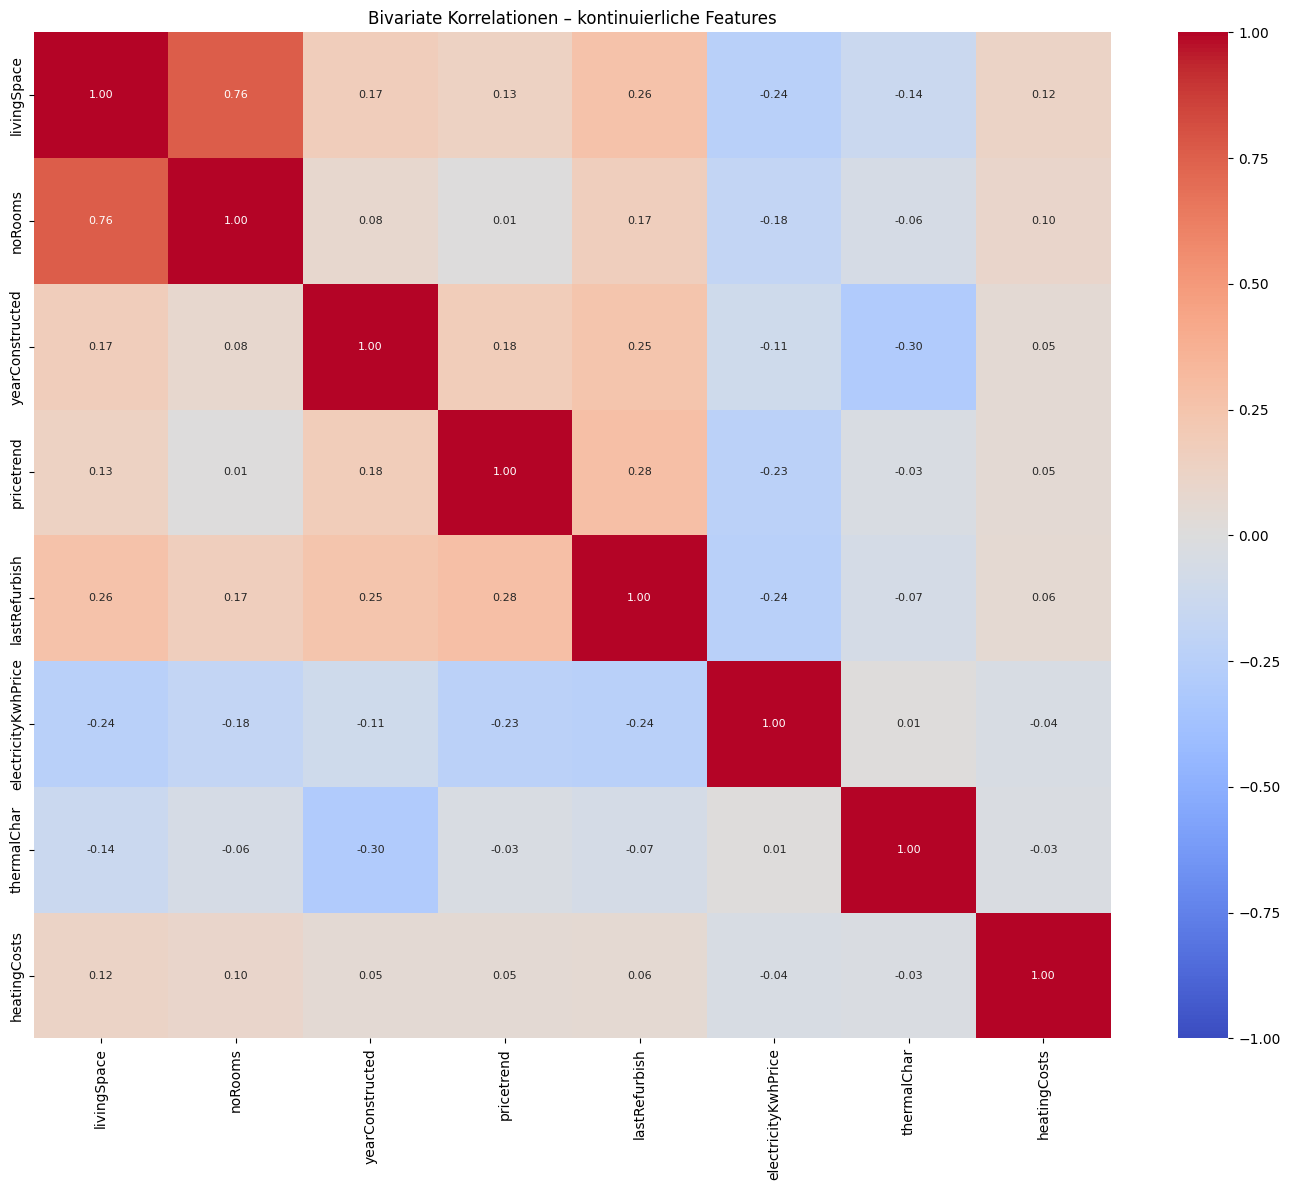


Paare mit |r| > 0.2 (kritisch bei n>1000):
pricetrend ↔ lastRefurbish: 0.285
pricetrend ↔ electricityKwhPrice: -0.234
telekomUploadSpeed ↔ telekom_info_missing: 0.231
yearConstructed ↔ thermalChar: -0.296
yearConstructed ↔ lastRefurbish: 0.247
yearConstructed ↔ noParkSpaces_missing: -0.313
livingSpace ↔ noRooms: 0.763
livingSpace ↔ lastRefurbish: 0.261
livingSpace ↔ electricityKwhPrice: -0.243
livingSpace ↔ noParkSpaces_missing: -0.258
lastRefurbish ↔ electricityKwhPrice: -0.245
lastRefurbish ↔ lastRefurbish_missing: 0.235
noParkSpaces_missing ↔ interiorQual_missing: 0.219
heatingCosts_missing ↔ firing_district_heating: -0.234
thermalChar_missing ↔ firing_district_heating: -0.206
thermalChar_missing ↔ firing_gas: 0.219
lastRefurbish_missing ↔ numberOfFloors_missing: 0.243
lastRefurbish_missing ↔ interiorQual_missing: 0.326
lastRefurbish_missing ↔ condition_missing: 0.265
numberOfFloors_missing ↔ interiorQual_missing: 0.334
numberOfFloors_missing ↔ condition_missing: 0.341
interiorQual

In [17]:
num_cols_continuous = ['livingSpace', 'noRooms', 'yearConstructed', 
                        'pricetrend', 'floor', 'lastRefurbish', 
                        'electricityKwhPrice', 'thermalChar', 'heatingCosts']
num_cols_continuous = [c for c in num_cols_continuous if c in X_final_train_outlier.columns]

corr_matrix_heatmap = X_final_train_outlier[num_cols_continuous].corr().round(3)
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix_heatmap, annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, fmt='.2f', annot_kws={'size': 8})
plt.title('Bivariate Korrelationen – kontinuierliche Features')
plt.tight_layout()
plt.show()

num_cols_all = X_final_train_outlier.select_dtypes(include=['number']).columns.tolist()
corr_matrix_full = X_final_train_outlier[num_cols_all].corr().round(3)

print("\nPaare mit |r| > 0.2 (kritisch bei n>1000):")
for i in range(len(corr_matrix_full)):
    for j in range(i+1, len(corr_matrix_full)):
        r = corr_matrix_full.iloc[i, j]
        if abs(r) > 0.2:
            print(f"{corr_matrix_full.index[i]} ↔ {corr_matrix_full.columns[j]}: {r:.3f}")

In [18]:
# Nur originale numerische Features, keine OHE
num_cols = [col for col in X_final_train_outlier.select_dtypes(include=['number']).columns
            if not any(col.startswith(prefix) for prefix in 
                      ['firingTypes', 'geo_', 'interiorQual', 'condition', 
                       'typeOfFlat', 'heatingType', 'energyEfficiency'])]

In [19]:
num_cols = X_final_train_outlier.select_dtypes(include=['number']).columns.tolist()
print(f"Anzahl numerische Spalten: {len(num_cols)}")
print(num_cols[:30])  # erste 30 anzeigen

Anzahl numerische Spalten: 37
['pricetrend', 'telekomUploadSpeed', 'yearConstructed', 'livingSpace', 'noRooms', 'thermalChar', 'heatingCosts', 'lastRefurbish', 'electricityKwhPrice', 'noParkSpaces_missing', 'heatingCosts_missing', 'thermalChar_missing', 'lastRefurbish_missing', 'numberOfFloors_missing', 'interiorQual_missing', 'typeOfFlat_missing', 'condition_missing', 'firing_bio_energy', 'firing_combined_heat_and_power_fossil_fuels', 'firing_combined_heat_and_power_renewable_energy', 'firing_district_heating', 'firing_electricity', 'firing_environmental_thermal_energy', 'firing_gas', 'firing_geothermal', 'firing_heat_supply', 'firing_liquid_gas', 'firing_local_heating', 'firing_natural_gas_heavy', 'firing_natural_gas_light']


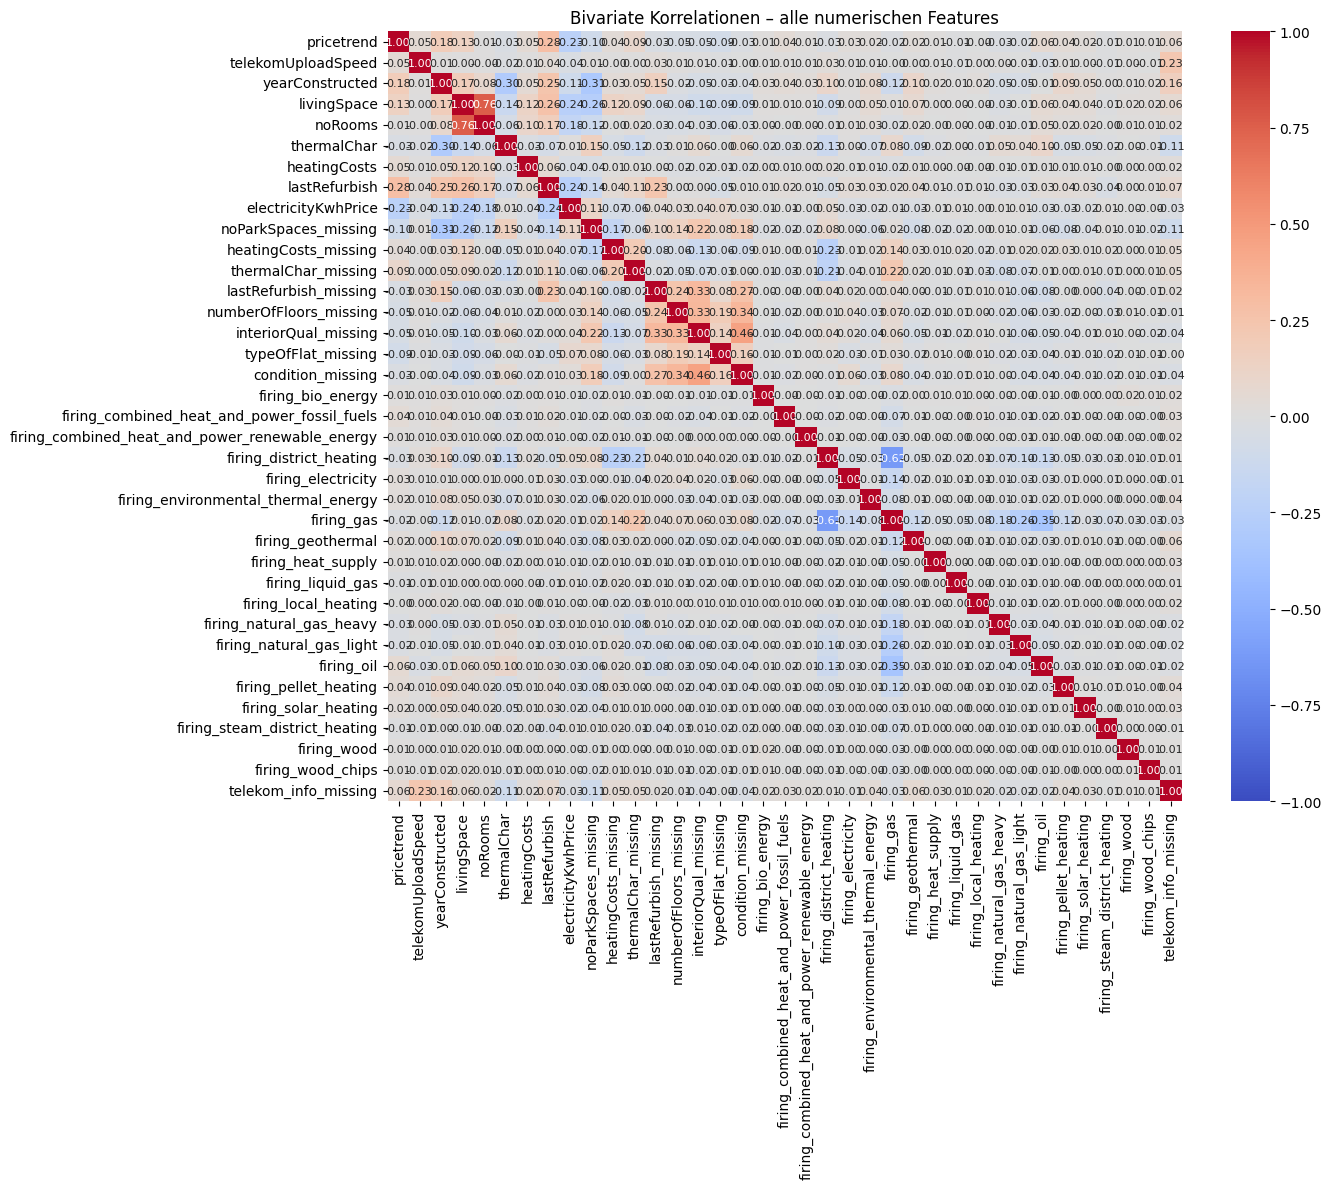


Paare mit |r| > 0.2 (kritisch bei n>1000):
pricetrend ↔ lastRefurbish: 0.285
pricetrend ↔ electricityKwhPrice: -0.234
telekomUploadSpeed ↔ telekom_info_missing: 0.231
yearConstructed ↔ thermalChar: -0.296
yearConstructed ↔ lastRefurbish: 0.247
yearConstructed ↔ noParkSpaces_missing: -0.313
livingSpace ↔ noRooms: 0.763
livingSpace ↔ lastRefurbish: 0.261
livingSpace ↔ electricityKwhPrice: -0.243
livingSpace ↔ noParkSpaces_missing: -0.258
lastRefurbish ↔ electricityKwhPrice: -0.245
lastRefurbish ↔ lastRefurbish_missing: 0.235
noParkSpaces_missing ↔ interiorQual_missing: 0.219
heatingCosts_missing ↔ firing_district_heating: -0.234
thermalChar_missing ↔ firing_district_heating: -0.206
thermalChar_missing ↔ firing_gas: 0.219
lastRefurbish_missing ↔ numberOfFloors_missing: 0.243
lastRefurbish_missing ↔ interiorQual_missing: 0.326
lastRefurbish_missing ↔ condition_missing: 0.265
numberOfFloors_missing ↔ interiorQual_missing: 0.334
numberOfFloors_missing ↔ condition_missing: 0.341
interiorQual

In [20]:
num_cols = X_final_train_outlier.select_dtypes(include=['number']).columns.tolist()

corr_matrix = X_final_train_outlier[num_cols].corr().round(3)

# Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, fmt='.2f', annot_kws={'size': 8})
plt.title('Bivariate Korrelationen – alle numerischen Features')
plt.tight_layout()
plt.show()

# Alle Paare über 0.2 printen
print("\nPaare mit |r| > 0.2 (kritisch bei n>1000):")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.2:
            print(f"{corr_matrix.index[i]} ↔ {corr_matrix.columns[j]}: {r:.3f}")

### 2.4 Modell Training

In [21]:
reg_outlier = LinearRegression().fit(X_final_train_outlier, y_train_outlier)
reg_isolation = LinearRegression().fit(X_final_train_isolation, y_train_isolation)
reg_hardlimits = LinearRegression().fit(X_final_train_hardlimits, y_train_hardlimits)

### 2.5 Evaluation
Wir evaluieren das Modell anhand von R² und RMSE:
- R² zeigt wie viel Varianz das Modell erklärt (1.0 = perfekt)
- RMSE zeigt den durchschnittlichen Fehler in Euro

<h2 id="5-regressionsmodell">5. Lineares Regressionsmodell</h2>

<h3 id="51-training">5.1. Modelltraining & Baseline</h3>

Es werden mehrere Regressionsvarianten (OLS, Ridge, Polynomial, Interaktionsterme) trainiert und über 5-fache Cross-Validation verglichen.

In [22]:
kf_fixed = KFold(n_splits=5, shuffle=True, random_state=42)

def rmse_euro(y_log_true, y_log_pred):
    return np.sqrt(mean_squared_error(np.exp(y_log_true), np.exp(y_log_pred)))
def mae_euro(y_log_true, y_log_pred):
    return mean_absolute_error(np.exp(y_log_true), np.exp(y_log_pred))

rmse_euro_scorer = make_scorer(rmse_euro, greater_is_better=False)
mae_euro_scorer = make_scorer(mae_euro, greater_is_better=False)

#Pipelines
ols_pipeline = make_pipeline(StandardScaler(), LinearRegression())
cv_pipeline = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 5, 50)))

In [23]:
# OLS/Ridge OHNE Log-Transformation, auf rohem y, mit CV=5
pipeline_no_log = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 5, 50)))

for name, X, y in [('outlier', X_final_train_outlier, y_train_outlier),
                    ('isolation', X_final_train_isolation, y_train_isolation),
                    ('hardlimits', X_final_train_hardlimits, y_train_hardlimits)]:
    rmse_vals = cross_val_score(pipeline_no_log, X, y, cv=kf_fixed, scoring='neg_root_mean_squared_error')
    print(f"{name}: RMSE (ohne Log, CV=5) = {-rmse_vals.mean():.2f}€ (± {(-rmse_vals).std():.2f})")
    print(f"  Einzelwerte pro Fold: {(-rmse_vals).round(2)}")

outlier: RMSE (ohne Log, CV=5) = 129.14€ (± 0.61)
  Einzelwerte pro Fold: [128.35 129.13 129.94 128.59 129.67]
isolation: RMSE (ohne Log, CV=5) = 129.44€ (± 1.62)
  Einzelwerte pro Fold: [129.3  127.81 129.31 132.46 128.31]
hardlimits: RMSE (ohne Log, CV=5) = 2471.72€ (± 2580.16)
  Einzelwerte pro Fold: [ 380.82 6167.89  337.76 5033.78  438.35]


In [24]:
datasets_ols_cv = [
    ('outlier', X_final_train_outlier, np.log(y_train_outlier)),
    ('isolation', X_final_train_isolation, np.log(y_train_isolation)),
    ('hardlimits', X_final_train_hardlimits, np.log(y_train_hardlimits))
]

print(f"{'='*50}\nOLS (LinearRegression, CV=5, fix)\n{'='*50}")
for name, X, y_log in datasets_ols_cv:
    r2_vals = cross_val_score(ols_pipeline, X, y_log, cv=kf_fixed, scoring='r2')
    rmse_e_vals = cross_val_score(ols_pipeline, X, y_log, cv=kf_fixed, scoring=rmse_euro_scorer)
    mae_e_vals = cross_val_score(ols_pipeline, X, y_log, cv=kf_fixed, scoring=mae_euro_scorer)
    print(f"--- {name.upper()} ---")
    print(f"  R² (Log):  {r2_vals.mean():.4f} (± {r2_vals.std():.4f})")
    print(f"  RMSE (€):  {-rmse_e_vals.mean():.2f} € (± {(-rmse_e_vals).std():.2f})")
    print(f"  MAE (€):   {-mae_e_vals.mean():.2f} €")
    print("-" * 40)

OLS (LinearRegression, CV=5, fix)
--- OUTLIER ---
  R² (Log):  0.9027 (± 0.0006)
  RMSE (€):  129.56 € (± 0.42)
  MAE (€):   78.81 €
----------------------------------------
--- ISOLATION ---
  R² (Log):  0.8923 (± 0.0050)
  RMSE (€):  2117.84 € (± 3973.00)
  MAE (€):   89.43 €
----------------------------------------
--- HARDLIMITS ---
  R² (Log):  0.6757 (± 0.2077)
  RMSE (€):  458198378552103387040556901126658588672.00 € (± 916396757104206925196841254081964015616.00)
  MAE (€):   2286594426983368289104334978633695232.00 €
----------------------------------------


In [25]:
ols_pipeline.fit(X_final_train_outlier, np.log(y_train_outlier))
coefs = ols_pipeline.named_steps['linearregression'].coef_
feature_names = X_final_train_outlier.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Koeffizient': coefs})
print(importance_df.sort_values('Koeffizient', key=abs, ascending=False).head(10))

                       Feature  Koeffizient
6                  livingSpace     0.220763
375        interiorQual_normal    -0.102508
391    energyEfficiencyClass_C    -0.078019
234            geo_krs_München     0.077820
374        condition_well_kept    -0.069766
131  geo_krs_Frankfurt_am_Main     0.055388
76              geo_krs_Berlin     0.054576
2                   pricetrend     0.046729
156            geo_krs_Hamburg     0.043216
327          geo_krs_Stuttgart     0.042038


In [26]:
datasets_mlr_cv = [
    ('outlier', X_final_train_outlier, np.log(y_train_outlier)),
    ('isolation', X_final_train_isolation, np.log(y_train_isolation)),
    ('hardlimits', X_final_train_hardlimits, np.log(y_train_hardlimits))
]

print(f"{'='*50}\nMLR (Ridge, CV=5, fix)\n{'='*50}")
for name, X, y_log in datasets_mlr_cv:
    r2_vals = cross_val_score(cv_pipeline, X, y_log, cv=kf_fixed, scoring='r2')
    rmse_e_vals = cross_val_score(cv_pipeline, X, y_log, cv=kf_fixed, scoring=rmse_euro_scorer)
    mae_e_vals = cross_val_score(cv_pipeline, X, y_log, cv=kf_fixed, scoring=mae_euro_scorer)
    print(f"--- {name.upper()} ---")
    print(f"  R² (Log):  {r2_vals.mean():.4f} (± {r2_vals.std():.4f})")
    print(f"  RMSE (€):  {-rmse_e_vals.mean():.2f} € (± {(-rmse_e_vals).std():.2f})")
    print(f"  MAE (€):   {-mae_e_vals.mean():.2f} €")
    print("-" * 40)

MLR (Ridge, CV=5, fix)
--- OUTLIER ---
  R² (Log):  0.9027 (± 0.0006)
  RMSE (€):  129.56 € (± 0.42)
  MAE (€):   78.81 €
----------------------------------------
--- ISOLATION ---
  R² (Log):  0.8923 (± 0.0050)
  RMSE (€):  2117.83 € (± 3972.98)
  MAE (€):   89.43 €
----------------------------------------
--- HARDLIMITS ---
  R² (Log):  0.6573 (± 0.1975)
  RMSE (€):  379140235340436094746717699649700888576.00 € (± 758280470680872189493435399299401777152.00)
  MAE (€):   1892062455380384838865453628136620032.00 €
----------------------------------------


In [27]:
cv_pipeline.fit(X_final_train_outlier, np.log(y_train_outlier))
coefs = cv_pipeline.named_steps['ridgecv'].coef_
feature_names = X_final_train_outlier.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Koeffizient': coefs})
print(importance_df.sort_values('Koeffizient', key=abs, ascending=False).head(10))

                       Feature  Koeffizient
6                  livingSpace     0.220681
375        interiorQual_normal    -0.102288
391    energyEfficiencyClass_C    -0.077853
234            geo_krs_München     0.077786
374        condition_well_kept    -0.069687
131  geo_krs_Frankfurt_am_Main     0.055361
76              geo_krs_Berlin     0.054529
2                   pricetrend     0.046762
156            geo_krs_Hamburg     0.043189
327          geo_krs_Stuttgart     0.042018


In [28]:
datasets_poly_cv = []
for name, X_train, y_train in [('outlier', X_final_train_outlier, y_train_outlier),
                                 ('isolation', X_final_train_isolation, y_train_isolation),
                                 ('hardlimits', X_final_train_hardlimits, y_train_hardlimits)]:
    poly = PolynomialFeatures(degree=2, include_bias=False)
    living_poly = poly.fit_transform(X_train[['livingSpace']])
    X_poly = X_train.copy()
    X_poly['livingSpace_sq'] = living_poly[:, 1]
    datasets_poly_cv.append((name, X_poly, np.log(y_train)))

print(f"{'='*50}\nPolynomial (Ridge, CV=5, fix)\n{'='*50}")
for name, X, y_log in datasets_poly_cv:
    r2_vals = cross_val_score(cv_pipeline, X, y_log, cv=kf_fixed, scoring='r2')
    rmse_e_vals = cross_val_score(cv_pipeline, X, y_log, cv=kf_fixed, scoring=rmse_euro_scorer)
    mae_e_vals = cross_val_score(cv_pipeline, X, y_log, cv=kf_fixed, scoring=mae_euro_scorer)
    print(f"--- {name.upper()} ---")
    print(f"  R² (Log):  {r2_vals.mean():.4f} (± {r2_vals.std():.4f})")
    print(f"  RMSE (€):  {-rmse_e_vals.mean():.2f} € (± {(-rmse_e_vals).std():.2f})")
    print(f"  MAE (€):   {-mae_e_vals.mean():.2f} €")
    print("-" * 40)

Polynomial (Ridge, CV=5, fix)
--- OUTLIER ---
  R² (Log):  0.9070 (± 0.0006)
  RMSE (€):  125.23 € (± 0.54)
  MAE (€):   76.88 €
----------------------------------------
--- ISOLATION ---
  R² (Log):  0.8985 (± 0.0050)
  RMSE (€):  125.85 € (± 1.45)
  MAE (€):   76.95 €
----------------------------------------
--- HARDLIMITS ---
  R² (Log):  0.6738 (± 0.1745)
  RMSE (€):  2536616337407047881115232901804326912.00 € (± 5073232674814096352526276162314305536.00)
  MAE (€):   12658737027482418698035003400388608.00 €
----------------------------------------


In [29]:
poly = PolynomialFeatures(degree=2, include_bias=False)
living_poly = poly.fit_transform(X_final_train_outlier[['livingSpace']])
X_poly = X_final_train_outlier.copy()
X_poly['livingSpace_sq'] = living_poly[:, 1]

cv_pipeline.fit(X_poly, np.log(y_train_outlier))
coefs = cv_pipeline.named_steps['ridgecv'].coef_
feature_names = X_poly.columns  # enthält jetzt zusätzlich livingSpace_sq

importance_df = pd.DataFrame({'Feature': feature_names, 'Koeffizient': coefs})
print(importance_df.sort_values('Koeffizient', key=abs, ascending=False).head(10))

                       Feature  Koeffizient
6                  livingSpace     0.401772
399             livingSpace_sq    -0.171496
375        interiorQual_normal    -0.104955
234            geo_krs_München     0.077391
391    energyEfficiencyClass_C    -0.075480
374        condition_well_kept    -0.070151
131  geo_krs_Frankfurt_am_Main     0.055125
76              geo_krs_Berlin     0.053081
2                   pricetrend     0.047736
156            geo_krs_Hamburg     0.042370


In [30]:
datasets_int_cv = []
for name, X_train, y_train in [('outlier', X_final_train_outlier, y_train_outlier),
                                 ('isolation', X_final_train_isolation, y_train_isolation),
                                 ('hardlimits', X_final_train_hardlimits, y_train_hardlimits)]:
    X_int = X_train.copy()
    X_int['livingSpace_x_pricetrend'] = X_int['livingSpace'] * X_int['pricetrend']
    datasets_int_cv.append((name, X_int, np.log(y_train)))

print(f"{'='*50}\nInteraktion livingSpace × pricetrend (Ridge, CV=5, fix)\n{'='*50}")
for name, X, y_log in datasets_int_cv:
    r2_vals = cross_val_score(cv_pipeline, X, y_log, cv=kf_fixed, scoring='r2')
    rmse_e_vals = cross_val_score(cv_pipeline, X, y_log, cv=kf_fixed, scoring=rmse_euro_scorer)
    mae_e_vals = cross_val_score(cv_pipeline, X, y_log, cv=kf_fixed, scoring=mae_euro_scorer)
    print(f"--- {name.upper()} ---")
    print(f"  R² (Log):  {r2_vals.mean():.4f} (± {r2_vals.std():.4f})")
    print(f"  RMSE (€):  {-rmse_e_vals.mean():.2f} € (± {(-rmse_e_vals).std():.2f})")
    print(f"  MAE (€):   {-mae_e_vals.mean():.2f} €")
    print("-" * 40)

Interaktion livingSpace × pricetrend (Ridge, CV=5, fix)
--- OUTLIER ---
  R² (Log):  0.9034 (± 0.0006)
  RMSE (€):  129.18 € (± 0.41)
  MAE (€):   78.56 €
----------------------------------------
--- ISOLATION ---
  R² (Log):  0.8931 (± 0.0049)
  RMSE (€):  1449.82 € (± 2637.98)
  MAE (€):   85.75 €
----------------------------------------
--- HARDLIMITS ---
  R² (Log):  0.6603 (± 0.1856)
  RMSE (€):  33966328712248609960586433384882896896.00 € (± 67932657424497229365905832509056221184.00)
  MAE (€):   169505658627469352779538596152475648.00 €
----------------------------------------


In [31]:
X_int = X_final_train_outlier.copy()
X_int['livingSpace_x_pricetrend'] = X_int['livingSpace'] * X_int['pricetrend']

cv_pipeline.fit(X_int, np.log(y_train_outlier))
coefs = cv_pipeline.named_steps['ridgecv'].coef_
feature_names = X_int.columns  # enthält jetzt zusätzlich livingSpace_x_pricetrend

importance_df = pd.DataFrame({'Feature': feature_names, 'Koeffizient': coefs})
print(importance_df.sort_values('Koeffizient', key=abs, ascending=False).head(10))

                       Feature  Koeffizient
6                  livingSpace     0.250551
375        interiorQual_normal    -0.103029
2                   pricetrend     0.089192
234            geo_krs_München     0.077198
391    energyEfficiencyClass_C    -0.076946
374        condition_well_kept    -0.069808
131  geo_krs_Frankfurt_am_Main     0.055206
399   livingSpace_x_pricetrend    -0.054971
76              geo_krs_Berlin     0.054288
156            geo_krs_Hamburg     0.043166


In [32]:
scores_outlier = cross_val_score(reg_outlier, X_final_train_outlier, y_train_outlier, cv=5, scoring='r2')
rmse_scores_outlier = cross_val_score(reg_outlier, X_final_train_outlier, y_train_outlier, cv=5, scoring='neg_root_mean_squared_error')
print(f"R² Mittelwert: {scores_outlier.mean():.4f}")
print(f"RMSE Mittelwert: {(-rmse_scores_outlier).mean():.2f}")


scores_isolation = cross_val_score(reg_isolation, X_final_train_isolation, y_train_isolation, 
                         cv=5, scoring='r2')

rmse_scores_isolation = cross_val_score(reg_isolation, X_final_train_isolation, y_train_isolation,
                              cv=5, 
                              scoring='neg_root_mean_squared_error')

print(f"R² pro Fold: {scores_isolation.round(4)}")
print(f"Mittelwert:  {scores_isolation.mean():.4f}")
print(f"Std:         {scores_isolation.std():.4f}")
print(f"RMSE pro Fold: {(-rmse_scores_isolation).round(2)}")


print("--------------")

scores_hardlimits = cross_val_score(reg_hardlimits, X_final_train_hardlimits, y_train_hardlimits, 
                         cv=5, scoring='r2')

rmse_scores_hardlimits = cross_val_score(reg_hardlimits, X_final_train_hardlimits, y_train_hardlimits,
                              cv=5, 
                              scoring='neg_root_mean_squared_error')

print(f"R² pro Fold: {scores_hardlimits.round(4)}")
print(f"Mittelwert:  {scores_hardlimits.mean():.4f}")
print(f"Std:         {scores_hardlimits.std():.4f}")
print(f"RMSE pro Fold: {(-rmse_scores_hardlimits).round(2)}")

R² Mittelwert: 0.8633
RMSE Mittelwert: 129.17
R² pro Fold: [0.8645 0.8607 0.8642 0.8595 0.8635]
Mittelwert:  0.8625
Std:         0.0020
RMSE pro Fold: [128.22 130.13 129.06 130.96 129.  ]
--------------
R² pro Fold: [ 0.4331  0.0062 -0.0349  0.0046  0.3313]
Mittelwert:  0.1480
Std:         0.1944
RMSE pro Fold: [ 376.04 4997.85  793.68 6164.21  473.05]


In [33]:
#Um die Features mit mehr als 10 Einzigartigen werten zu filtern
continuous_cols = [col for col in X_final_train_outlier.columns 
                   if X_final_train_outlier[col].nunique() > 10]
print(continuous_cols)

['pricetrend', 'yearConstructed', 'livingSpace', 'noRooms', 'thermalChar', 'heatingCosts', 'lastRefurbish', 'electricityKwhPrice']


In [34]:
UHH_Rot = (227/255, 0/255, 11/255)
Rot_50 = (240/255, 130/255, 136/255)
Rot_35 = (245/255, 170/255, 170/255)
Rot_20 = (250/255, 208/255, 205/255)


UHH_Steingrau = (59/255, 80/255, 88/255)


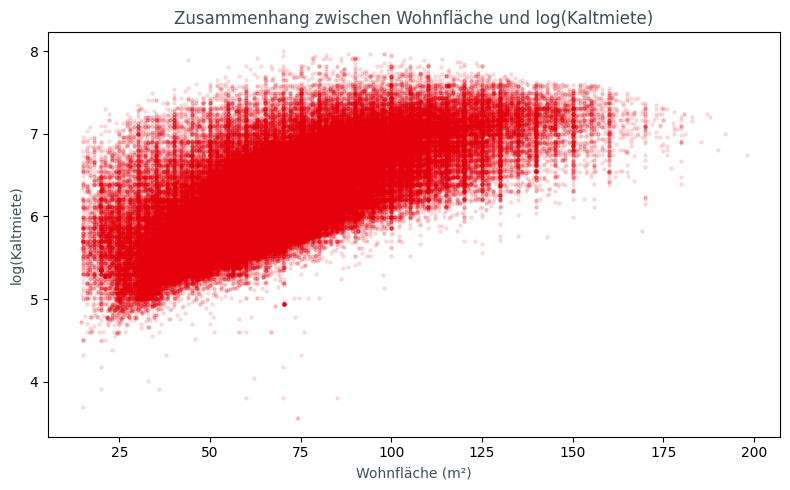

In [35]:

plt.figure(figsize=(8, 5))
plt.scatter(X_final_train_outlier['livingSpace'], np.log(y_train_outlier), alpha=0.1, s=5, color=UHH_Rot)
plt.xlabel('Wohnfläche (m²)', color=UHH_Steingrau)
plt.ylabel('log(Kaltmiete)', color=UHH_Steingrau)
plt.title('Zusammenhang zwischen Wohnfläche und log(Kaltmiete)', color=UHH_Steingrau)
plt.tight_layout()
plt.savefig('livingspace_krümmung.png', dpi=300)
plt.show()


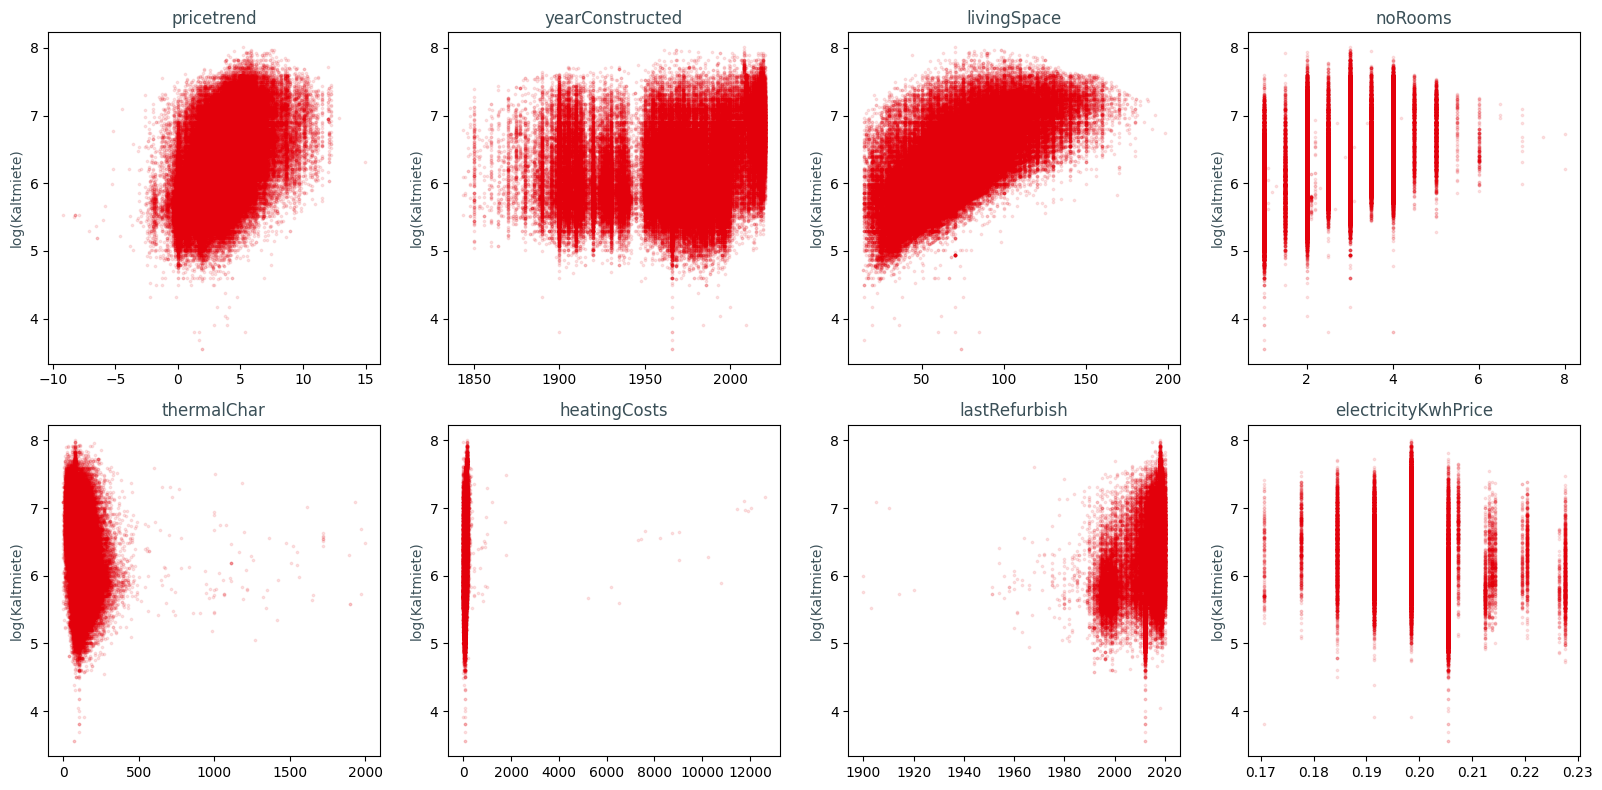

In [36]:
continuous_cols = ['pricetrend', 'yearConstructed', 'livingSpace', 'noRooms', 
                   'thermalChar', 'heatingCosts', 'lastRefurbish', 'electricityKwhPrice']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, col in zip(axes.flat, continuous_cols):
    ax.scatter(X_final_train_outlier[col], np.log(y_train_outlier), 
               alpha=0.1, s=3, color=UHH_Rot)
    ax.set_title(col, color=UHH_Steingrau)
    ax.set_ylabel('log(Kaltmiete)', color=UHH_Steingrau)

plt.tight_layout()
plt.savefig('scatter_grid_alle_variablen.png', dpi=300)
plt.show()

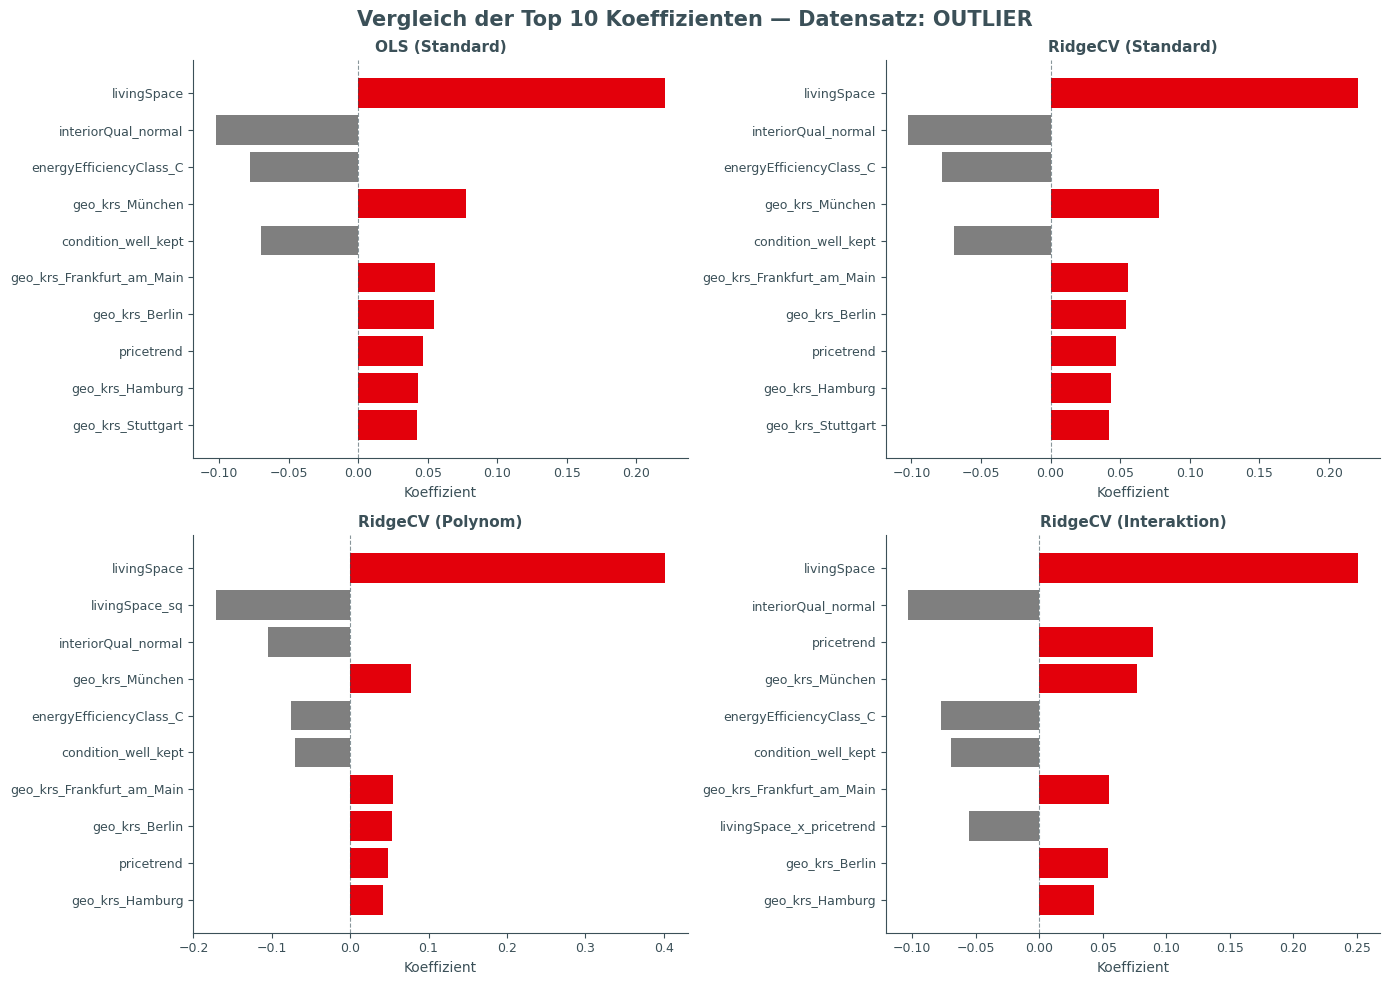

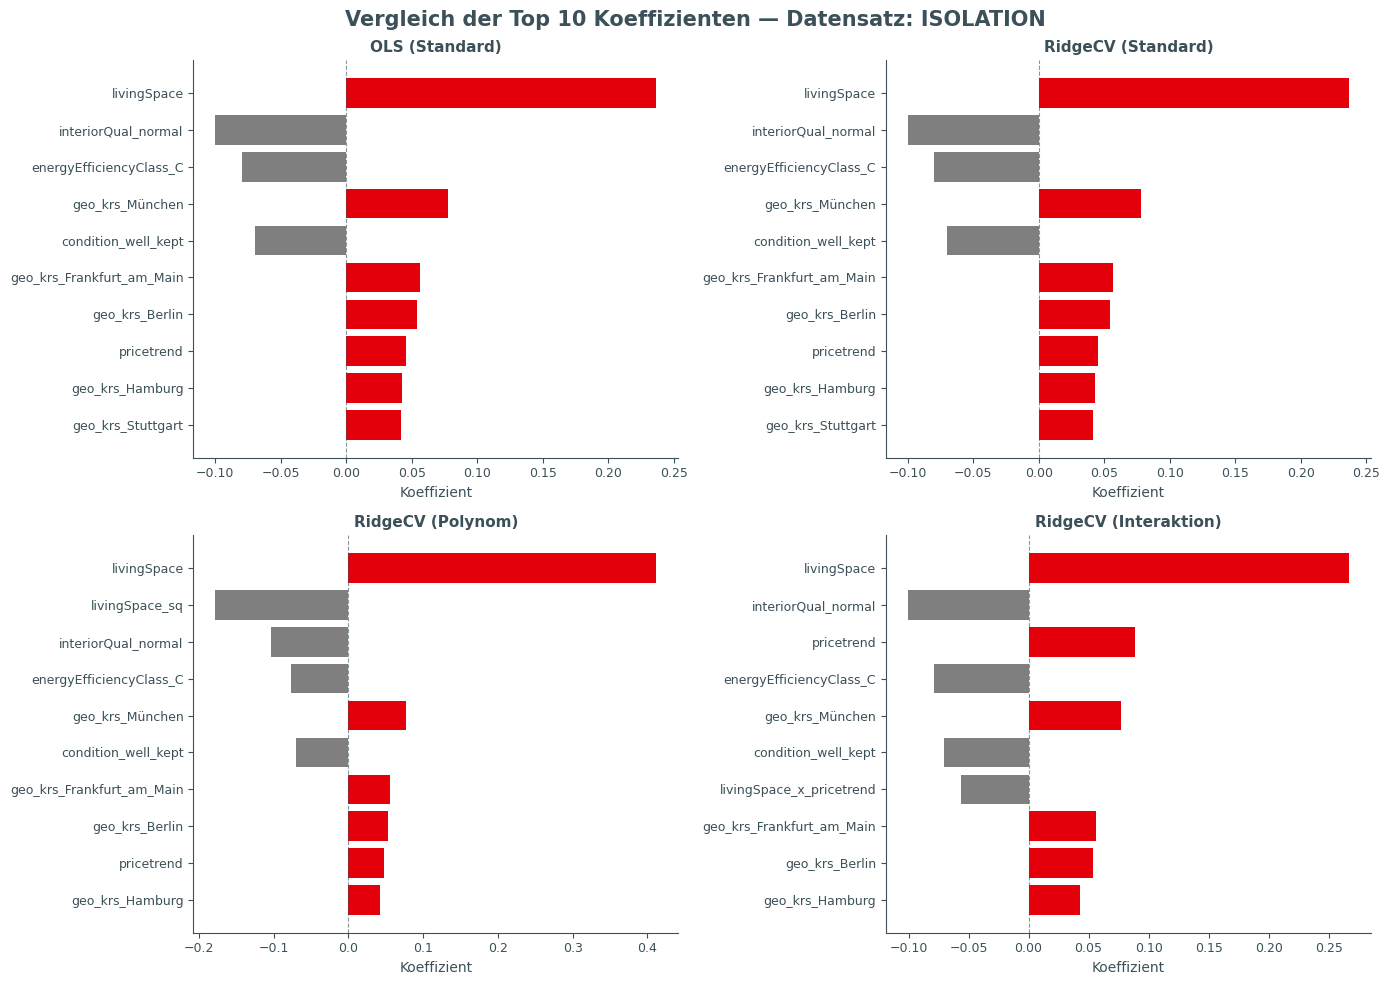

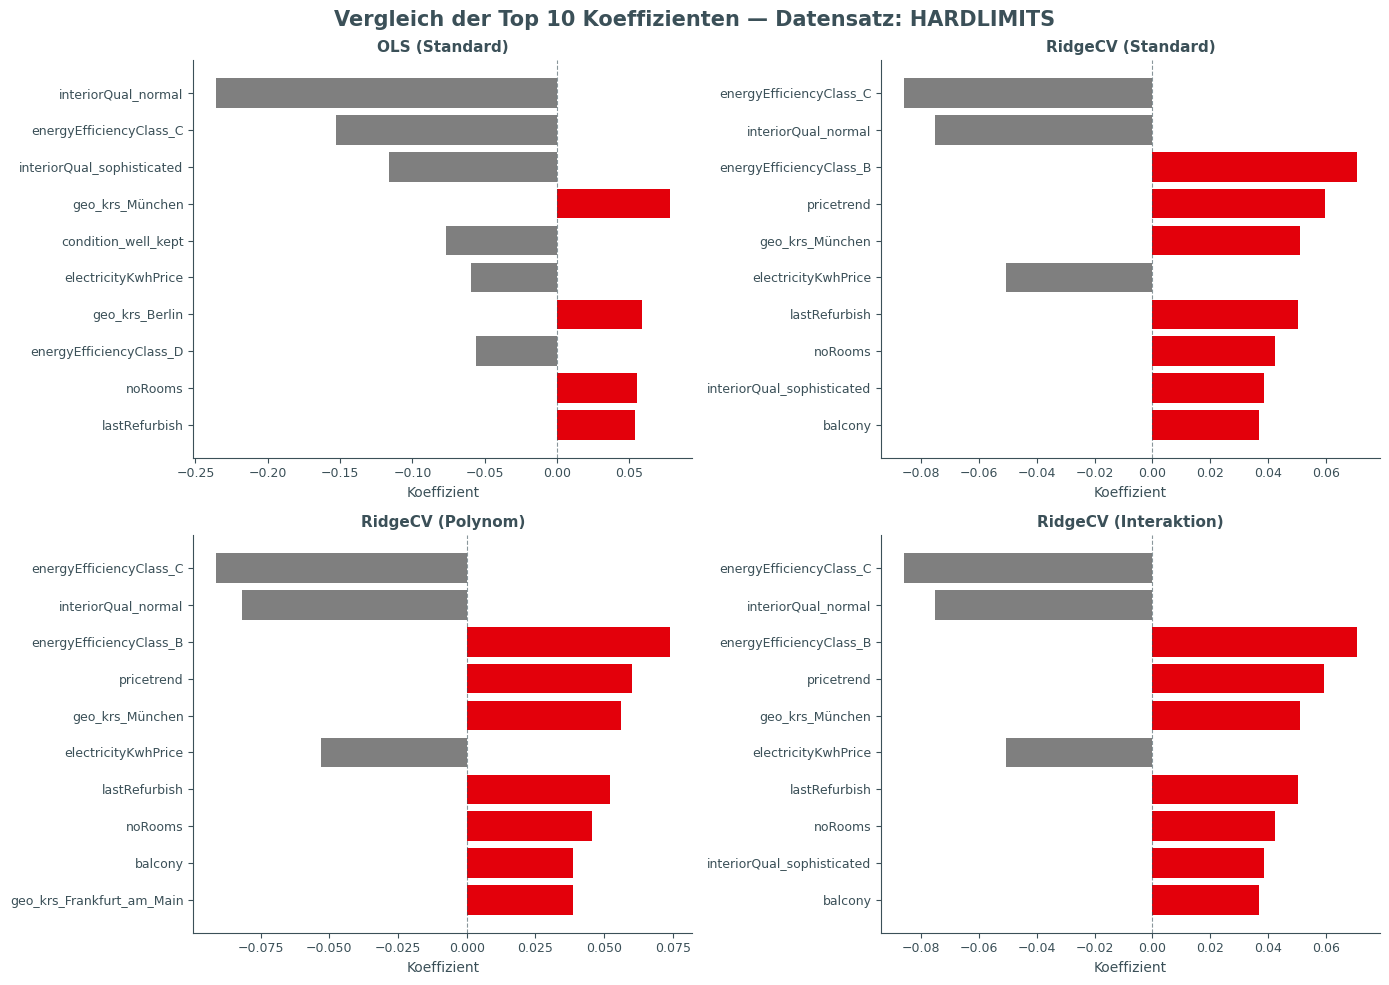

In [37]:
datasets = {
    'outlier': (X_final_train_outlier, y_train_outlier),
    'isolation': (X_final_train_isolation, y_train_isolation),
    'hardlimits': (X_final_train_hardlimits, y_train_hardlimits),
}

for ds_name, (X_train, y_train) in datasets.items():
  y_log = np.log(y_train)


  # OLS Standard
  ols_pipeline.fit(X_train, y_log)
  df_ols = pd.DataFrame({
      'Feature': X_train.columns,
      'Koeffizient': ols_pipeline.named_steps['linearregression'].coef_,
  }).sort_values('Koeffizient', key=abs, ascending=False)

  # RidgeCV Standard
  cv_pipeline.fit(X_train, y_log)
  df_ridge = pd.DataFrame({
      'Feature': X_train.columns,
      'Koeffizient': cv_pipeline.named_steps['ridgecv'].coef_,
  }).sort_values('Koeffizient', key=abs, ascending=False)

  # RidgeCV Poly
  poly = PolynomialFeatures(degree=2, include_bias=False)
  living_poly = poly.fit_transform(X_train[['livingSpace']])
  X_poly = X_train.copy()
  X_poly['livingSpace_sq'] = living_poly[:, 1]
  cv_pipeline.fit(X_poly, y_log)
  df_poly = pd.DataFrame({
      'Feature': X_poly.columns,
      'Koeffizient': cv_pipeline.named_steps['ridgecv'].coef_,
  }).sort_values('Koeffizient', key=abs, ascending=False)

  # RidgeCV Interaktion
  X_int = X_train.copy()
  X_int['livingSpace_x_pricetrend'] = X_int['livingSpace'] * X_int['pricetrend']
  cv_pipeline.fit(X_int, y_log)
  df_int = pd.DataFrame({
      'Feature': X_int.columns,
      'Koeffizient': cv_pipeline.named_steps['ridgecv'].coef_,
  }).sort_values('Koeffizient', key=abs, ascending=False)

  
  fig, axes = plt.subplots(2, 2, figsize=(14, 10))
  axes_flat = axes.flatten()

  models_data = [
      ('OLS (Standard)', df_ols),
      ('RidgeCV (Standard)', df_ridge),
      ('RidgeCV (Polynom)', df_poly),
      ('RidgeCV (Interaktion)', df_int),
  ]

  for i, (model_label, df) in enumerate(models_data):
    ax = axes_flat[i]
    top10 = df.head(10)

    # Farben: Positiv UHH_Rot, Negativ Grau
    bar_colors = [
        UHH_Rot if c >= 0 else '#7f7f7f' for c in top10['Koeffizient'][::-1]
    ]

    ax.barh(
        top10['Feature'][::-1], top10['Koeffizient'][::-1], color=bar_colors
    )

    ax.set_title(
        model_label, color=UHH_Steingrau, fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Koeffizient', color=UHH_Steingrau, fontsize=10)
    ax.tick_params(colors=UHH_Steingrau, labelsize=9)
    ax.axvline(0, color=UHH_Steingrau, linestyle='--', linewidth=0.8, alpha=0.6)

    for spine in ['top', 'right']:
      ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
      ax.spines[spine].set_color(UHH_Steingrau)

  fig.suptitle(
      f'Vergleich der Top 10 Koeffizienten — Datensatz: {ds_name.upper()}',
      color=UHH_Steingrau,
      fontsize=15,
      fontweight='bold',
      y=0.98,
  )

  plt.tight_layout()
  filename = f'feature_coefs_grid_{ds_name}.png'
  plt.savefig(filename, dpi=300, bbox_inches='tight')
  plt.show()

In [38]:
# Baseline
scaler_unlog = StandardScaler()
X_scaled_unlog = scaler_unlog.fit_transform(X_final_train_outlier)
X_sm_unlog = sm.add_constant(X_scaled_unlog, has_constant='add')
model_unlog = sm.OLS(y_train_outlier.astype(float), X_sm_unlog).fit()

fitted_unlog, residuen_unlog = model_unlog.fittedvalues, model_unlog.resid
lm_stat, lm_p, f_stat, f_p = het_breuschpagan(residuen_unlog, X_sm_unlog)
print(f"Breusch-Pagan (roh): p={lm_p:.4f} → {'Heteroskedastizität' if lm_p < 0.05 else 'Homoskedastizität'}")

Breusch-Pagan (roh): p=0.0000 → Heteroskedastizität


In [39]:
rng = np.random.default_rng(42)
stichprobe = rng.choice(residuen_unlog, size=5000, replace=False)

stat, p = shapiro(stichprobe)
print(f"Shapiro-Wilk (roh, n=5000): W={stat:.4f}, p={p:.4g}")
print("→ Normalität abgelehnt" if p < 0.05 else "→ Normalität")

Shapiro-Wilk (roh, n=5000): W=0.8929, p=2.27e-50
→ Normalität abgelehnt


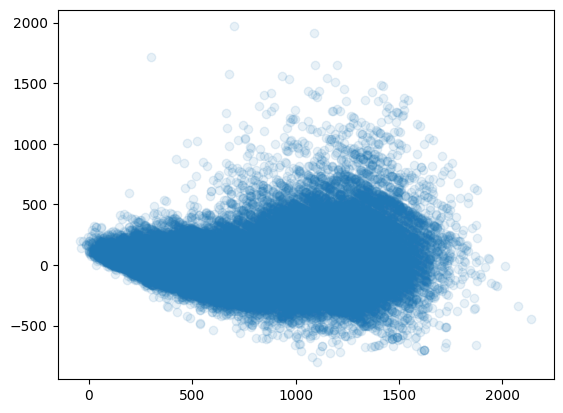

In [40]:
y_pred_train_outlier = reg_outlier.predict(X_final_train_outlier)
residuen_outlier = y_train_outlier - y_pred_train_outlier
plt.scatter(y_pred_train_outlier, residuen_outlier, alpha=0.1)

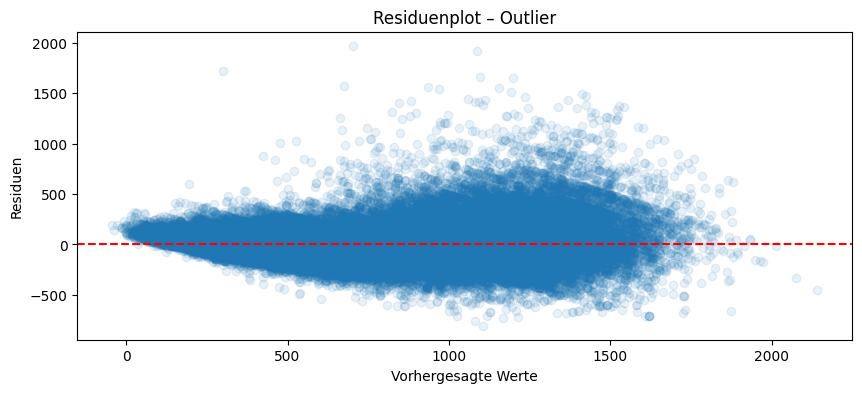

In [41]:
plt.figure(figsize=(10, 4))
plt.scatter(y_pred_train_outlier, residuen_outlier, alpha=0.1)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Vorhergesagte Werte')
plt.ylabel('Residuen')
plt.title('Residuenplot – Outlier')
plt.show()

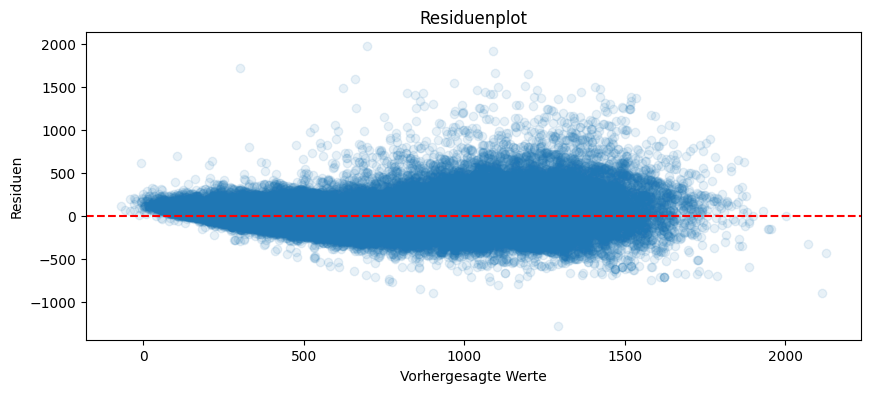

In [42]:
# Residuen berechnen
y_pred_train_isolation = reg_isolation.predict(X_final_train_isolation)
residuen_isolation = y_train_isolation - y_pred_train_isolation


plt.figure(figsize=(10, 4))
plt.scatter(y_pred_train_isolation, residuen_isolation, alpha=0.1)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Vorhergesagte Werte')
plt.ylabel('Residuen')
plt.title('Residuenplot')
plt.show()

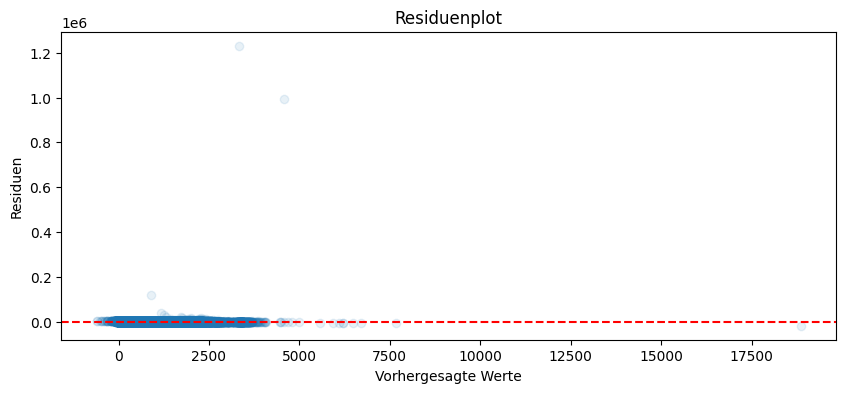

In [43]:
# Residuen berechnen
y_pred_train_hardlimits = reg_hardlimits.predict(X_final_train_hardlimits)
residuen_hardlimits = y_train_hardlimits - y_pred_train_hardlimits



plt.figure(figsize=(10, 4))
plt.scatter(y_pred_train_hardlimits, residuen_hardlimits, alpha=0.1)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Vorhergesagte Werte')
plt.ylabel('Residuen')
plt.title('Residuenplot')
plt.show()

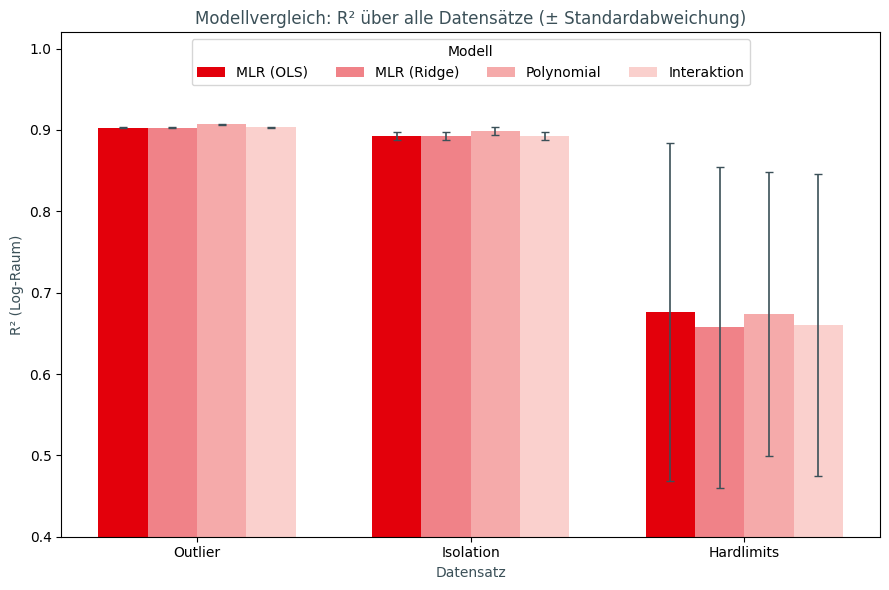

In [44]:
datasets = ['Outlier', 'Isolation', 'Hardlimits']
models = ['MLR (OLS)', 'MLR (Ridge)', 'Polynomial', 'Interaktion']

mean = np.array([
    [0.9027, 0.9027, 0.9070, 0.9034],   # Outlier
    [0.8923, 0.8923, 0.8985, 0.8931],   # Isolation
    [0.6757, 0.6573, 0.6738, 0.6603],   # Hardlimits
])
std = np.array([
    [0.0006, 0.0006, 0.0006, 0.0006],
    [0.0050, 0.0050, 0.0050, 0.0049],
    [0.2077, 0.1975, 0.1745, 0.1856],
])

colors = [UHH_Rot, Rot_50, Rot_35, Rot_20]

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(datasets))
width = 0.18

for i, (m, c) in enumerate(zip(models, colors)):
    ax.bar(x + (i - 1.5) * width, mean[:, i], width, yerr=std[:, i],
           color=c, label=m, capsize=3,
           error_kw=dict(ecolor=UHH_Steingrau, elinewidth=1.2))

ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_xlabel('Datensatz', color=UHH_Steingrau)
ax.set_ylabel('R² (Log-Raum)', color=UHH_Steingrau)
ax.set_title('Modellvergleich: R² über alle Datensätze (± Standardabweichung)',
             color=UHH_Steingrau)
ax.set_ylim(0.4, 1.02)
ax.legend(title='Modell', loc='upper center', ncol=4, frameon=True)

plt.tight_layout()
plt.savefig('Modellvergleich.png', dpi=300, bbox_inches='tight')
plt.show()

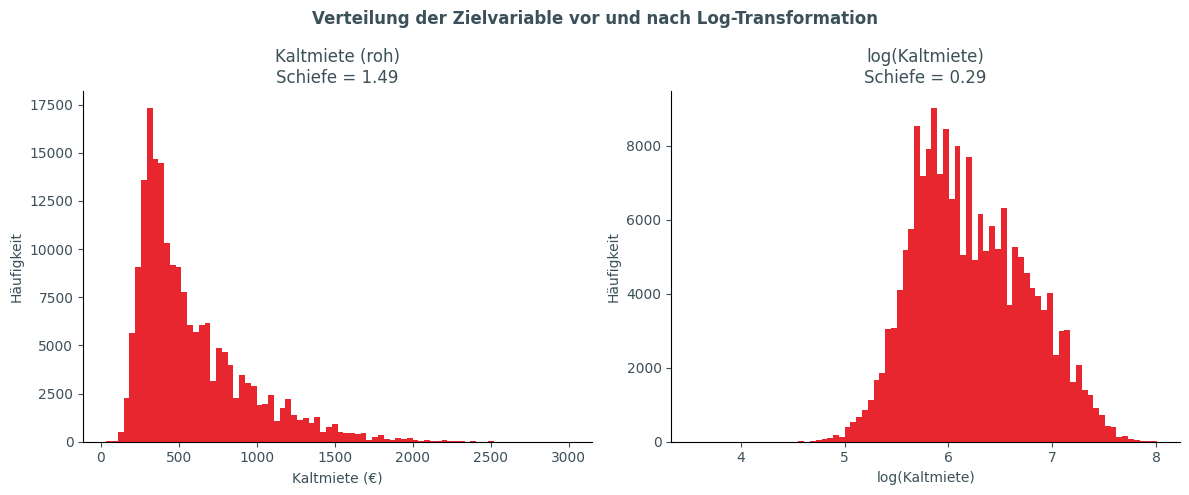

In [45]:
from scipy.stats import skew

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(y_train_outlier, bins=80, color=UHH_Rot, alpha=0.85)
axes[0].set_title(f'Kaltmiete (roh)\nSchiefe = {skew(y_train_outlier):.2f}',
                   color=UHH_Steingrau)
axes[0].set_xlabel('Kaltmiete (€)', color=UHH_Steingrau)
axes[0].set_ylabel('Häufigkeit', color=UHH_Steingrau)

log_rent = np.log(y_train_outlier)
axes[1].hist(log_rent, bins=80, color=UHH_Rot, alpha=0.85)
axes[1].set_title(f'log(Kaltmiete)\nSchiefe = {skew(log_rent):.2f}',
                   color=UHH_Steingrau)
axes[1].set_xlabel('log(Kaltmiete)', color=UHH_Steingrau)
axes[1].set_ylabel('Häufigkeit', color=UHH_Steingrau)

for ax in axes:
    ax.tick_params(colors=UHH_Steingrau)
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)

fig.suptitle('Verteilung der Zielvariable vor und nach Log-Transformation',
             color=UHH_Steingrau, fontweight='bold')
plt.tight_layout()
plt.savefig('rechtsschief.png', dpi=300, bbox_inches='tight')
plt.show()

Outlier    | Shapiro-Wilk roh: p=2.27e-50 (abgelehnt)  |  log: p=1.376e-26 (abgelehnt)
Isolation  | Shapiro-Wilk roh: p=1.633e-56 (abgelehnt)  |  log: p=1.2e-60 (abgelehnt)
Hardlimits | Shapiro-Wilk roh: p=3.781e-65 (abgelehnt)  |  log: p=2.766e-53 (abgelehnt)


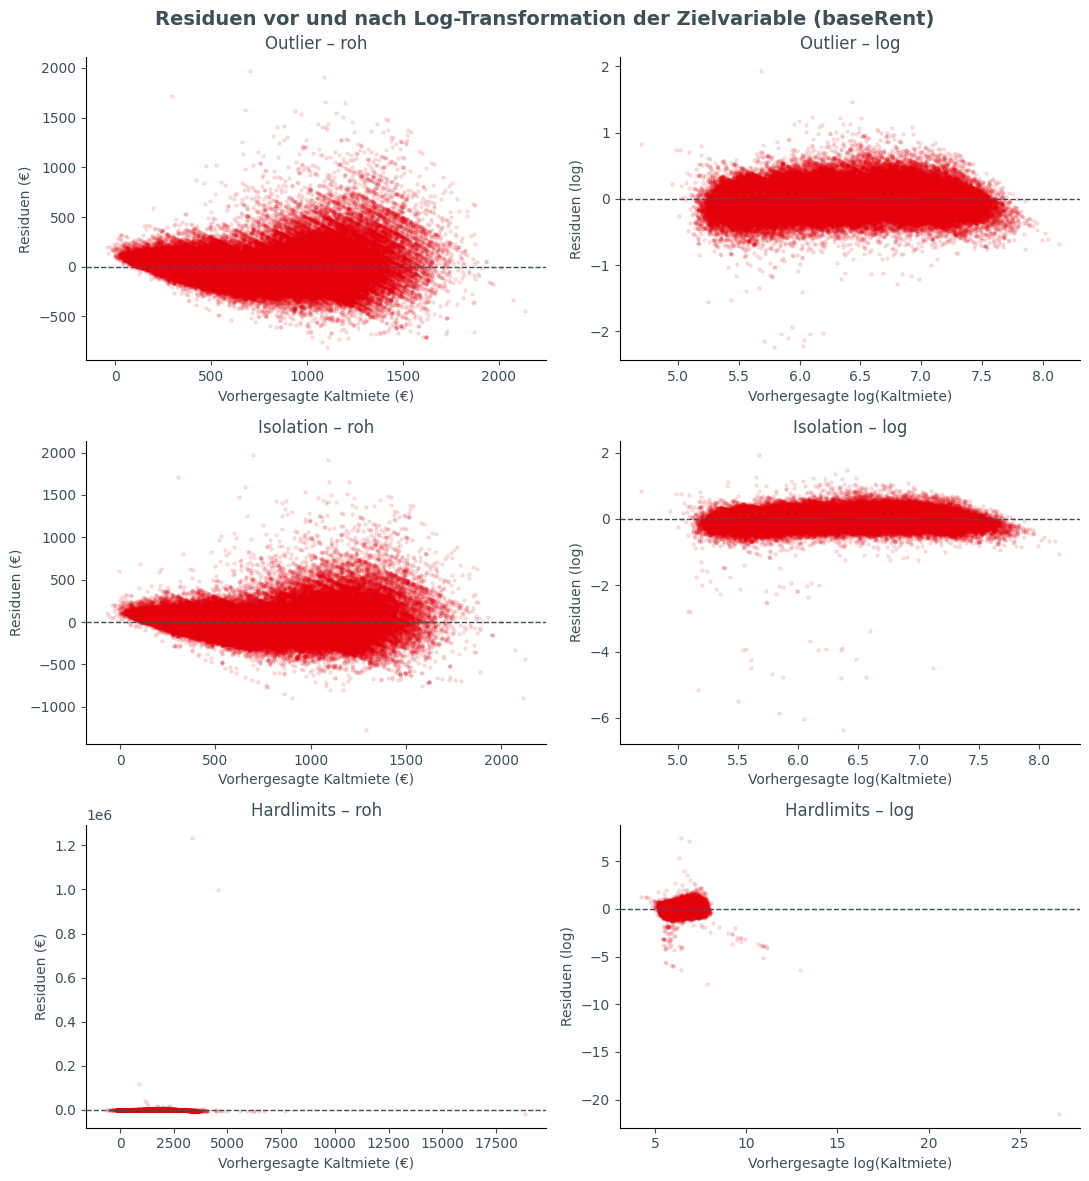

In [46]:
from scipy.stats import shapiro

# --- Log-Modelle zusätzlich zu den bereits vorhandenen rohen reg_* fitten ---
reg_log_outlier    = LinearRegression().fit(X_final_train_outlier, np.log(y_train_outlier))
reg_log_isolation  = LinearRegression().fit(X_final_train_isolation, np.log(y_train_isolation))
reg_log_hardlimits = LinearRegression().fit(X_final_train_hardlimits, np.log(y_train_hardlimits))

datensaetze = [
    ('Outlier',    X_final_train_outlier,    y_train_outlier,    reg_outlier,    reg_log_outlier),
    ('Isolation',  X_final_train_isolation,  y_train_isolation,  reg_isolation,  reg_log_isolation),
    ('Hardlimits', X_final_train_hardlimits, y_train_hardlimits, reg_hardlimits, reg_log_hardlimits),
]

residuen_roh = {}
residuen_log = {}

# --- Shapiro-Wilk-Test für alle drei Datensätze (roh und log) ---
rng = np.random.default_rng(42)
for name, X, y, reg_r, reg_l in datensaetze:
    res_roh = y - reg_r.predict(X)
    res_log = np.log(y) - reg_l.predict(X)
    residuen_roh[name] = res_roh
    residuen_log[name] = res_log

    stat_r, p_r = shapiro(rng.choice(res_roh, size=5000, replace=False))
    stat_l, p_l = shapiro(rng.choice(res_log, size=5000, replace=False))
    print(f"{name:10s} | Shapiro-Wilk roh: p={p_r:.4g} "
          f"({'abgelehnt' if p_r < 0.05 else 'bestanden'})  |  "
          f"log: p={p_l:.4g} ({'abgelehnt' if p_l < 0.05 else 'bestanden'})")

# --- Gegenüberstellung roh vs. log, für alle drei Datensätze ---
fig, axes = plt.subplots(3, 2, figsize=(11, 12))

for row, (name, X, y, reg_r, reg_l) in enumerate(datensaetze):
    pred_roh = reg_r.predict(X)
    pred_log = reg_l.predict(X)

    axes[row, 0].scatter(pred_roh, residuen_roh[name], alpha=0.1, s=5, color=UHH_Rot)
    axes[row, 0].axhline(0, color=UHH_Steingrau, linestyle='--', linewidth=1)
    axes[row, 0].set_title(f'{name} – roh', color=UHH_Steingrau)
    axes[row, 0].set_xlabel('Vorhergesagte Kaltmiete (€)', color=UHH_Steingrau)
    axes[row, 0].set_ylabel('Residuen (€)', color=UHH_Steingrau)

    axes[row, 1].scatter(pred_log, residuen_log[name], alpha=0.1, s=5, color=UHH_Rot)
    axes[row, 1].axhline(0, color=UHH_Steingrau, linestyle='--', linewidth=1)
    axes[row, 1].set_title(f'{name} – log', color=UHH_Steingrau)
    axes[row, 1].set_xlabel('Vorhergesagte log(Kaltmiete)', color=UHH_Steingrau)
    axes[row, 1].set_ylabel('Residuen (log)', color=UHH_Steingrau)

for ax in axes.flat:
    ax.tick_params(colors=UHH_Steingrau)
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)

fig.suptitle('Residuen vor und nach Log-Transformation der Zielvariable (baseRent)',
             color=UHH_Steingrau, fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('residuen_roh_vs_log_alle_datensaetze.png', dpi=300, bbox_inches='tight')
plt.show()

<hr style="height:10px; border:none; border-radius: 25px; background-image: linear-gradient(to right, #3df5dc, #1fc0cf, #478aa7, #4c5a6d, #333333);">